# FabricCo Data Challenge — External & Internal Analysis

This notebook supports **Part 1** (Google Trends) and **Part 2** (FabricCo KPIs).  
Use outputs and markdown sections as draft material for the final report (max 8 pages).

**Important:** Google Trends values are **relative search interest (0–100)**, not absolute market demand. Interpret **patterns, seasonality, and timing** only.

Google Trends measures relative search interest within each market and period. It is used here to analyze timing and seasonality, not absolute market demand.

Non-technical reviewers can open **FabricCo_Analysis_Package.xlsx** in this folder for the same tables, correlations, embedded chart thumbnails, and assignment-aligned answers as the notebook (regenerate with `python3 build_analysis_package_xlsx.py` after data or chart changes).


## 0. Load all relevant files, print column names, dataset structure

The code below discovers files in this folder, loads tabular assets, prints schemas, and briefly describes each dataset.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

def _project_root() -> Path:
    """Resolve project folder even if the Jupyter kernel cwd is elsewhere."""
    start = Path.cwd().resolve()
    for d in [start, *start.parents]:
        if (d / "FabricCo_Full_Products_Corrected_KPIs_2004_2024.csv").exists():
            return d
    return start


BASE = _project_root()
print("Workspace:", BASE)

import matplotlib.dates as mdates

CHART_DIR = BASE / "outputs" / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)
print("Charts export to:", CHART_DIR.resolve())


def _chart_style():
    plt.rcParams.update(
        {
            "figure.facecolor": "white",
            "axes.facecolor": "white",
            "axes.edgecolor": "#374151",
            "axes.labelcolor": "#111827",
            "axes.titleweight": "semibold",
            "axes.titlesize": 13,
            "axes.labelsize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": False,
            "legend.frameon": False,
        }
    )


def _save_chart(fig, filename: str):
    fig.savefig(CHART_DIR / filename, dpi=240, bbox_inches="tight", facecolor="white")

def _deck_titles(fig, title, subtitle):
    """Title = claim; subtitle = why it matters (slide style)."""
    fig.suptitle(
        title,
        fontsize=15,
        fontweight="semibold",
        color="#0f172a",
        x=0.5,
        y=0.97,
        ha="center",
    )
    fig.text(
        0.5,
        0.88,
        subtitle,
        fontsize=10,
        color="#64748b",
        ha="center",
        va="top",
        linespacing=1.35,
    )


def _label_line_end(ax, dates, y, name, color="#0f172a", dx=8, dy=0):
    """Direct label at series end (no legend)."""
    xi = dates.iloc[-1]
    yi = float(y.iloc[-1])
    ax.annotate(
        name,
        xy=(xi, yi),
        xytext=(dx, dy),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="semibold",
        color=color,
    )




# --- Discover files ---
tabular = sorted(BASE.glob("*.csv")) + sorted(BASE.glob("*.xlsx"))
pdfs = sorted(BASE.glob("*.pdf"))
print("\nTabular files:", [p.name for p in tabular])
print("PDFs:", [p.name for p in pdfs])

fabric_path = BASE / "FabricCo_Full_Products_Corrected_KPIs_2004_2024.csv"
combined_path = BASE / "UK_NZ_combined.xlsx"
uk_path = BASE / "UK_swimsuit_scarf_clean_v2.xlsx"
nz_path = BASE / "NZ_swimsuit_scarf_clean_2004_2026.xlsx"

# --- FabricCo internal CSV ---
fabric = pd.read_csv(fabric_path)
print("\n" + "=" * 72)
print("DATASET: FabricCo_Full_Products_Corrected_KPIs_2004_2024.csv")
print("Shape:", fabric.shape)
print("Columns (" + str(len(fabric.columns)) + "):")
for c in fabric.columns:
    print("  -", c)

# --- Google Trends combined (primary source for Part 1) ---
trends_combined = pd.read_excel(combined_path, sheet_name="Sheet1", header=0)
print("\n" + "=" * 72)
print("DATASET: UK_NZ_combined.xlsx [Sheet1]")
print("Shape:", trends_combined.shape)
print("Columns:")
for c in trends_combined.columns:
    print("  -", repr(c))

# --- Optional per-country workbooks (may be unreadable depending on export) ---
for label, p in [("UK_swimsuit_scarf_clean_v2.xlsx", uk_path), ("NZ_swimsuit_scarf_clean_2004_2026.xlsx", nz_path)]:
    print("\n" + "=" * 72)
    print("DATASET:", p.name)
    if not p.exists():
        print("  (file missing)")
        continue
    try:
        xl = pd.ExcelFile(p, engine="openpyxl")
        print("Sheets:", xl.sheet_names)
        if xl.sheet_names:
            peek = pd.read_excel(p, sheet_name=xl.sheet_names[0], header=None, nrows=3)
            print(peek)
        else:
            print("  Note: workbook reports no sheets via openpyxl/pandas — file may need re-export.")
    except Exception as e:
        print("  Could not read:", e)


Workspace: /Users/asauliuk/Library/CloudStorage/OneDrive-SanFranciscoStateUniversity/data challenge 1
Charts export to: /Users/asauliuk/Library/CloudStorage/OneDrive-SanFranciscoStateUniversity/data challenge 1/outputs/charts

Tabular files: ['FabricCo_Full_Products_Corrected_KPIs_2004_2024.csv', 'UK_NZ_combined.xlsx', '~$FabricCo_internal_analysis.xlsx', '~$UK_NZ_combined.xlsx']
PDFs: ['Data Challenge-Google Trends.pdf']

DATASET: FabricCo_Full_Products_Corrected_KPIs_2004_2024.csv
Shape: (252, 51)
Columns (51):
  - Date
  - Beanies_COGS
  - Beanies_Sold_Units
  - Beanies_Gross_Profit_Margin
  - Beanies_Production_Cost
  - Beanies_Inventory_Turnover
  - Beanies_Capacity_Utilization
  - Beanies_Lead_Time_Days
  - Beanies_Market_Share
  - Beanies_Customer_Satisfaction_Score
  - Beanies_Items_Returned
  - Bikinis_COGS
  - Bikinis_Sold_Units
  - Bikinis_Gross_Profit_Margin
  - Bikinis_Production_Cost
  - Bikinis_Inventory_Turnover
  - Bikinis_Capacity_Utilization
  - Bikinis_Lead_Time_Day

### What each dataset contains

| Dataset | Contents |
|--------|-----------|
| **FabricCo_Full_Products_Corrected_KPIs_2004_2024.csv** | One row per **month-end** (`Date`). Wide format: for each product (**Beanies**, **Bikinis**, **Hoodies**, **Summer_Shirts**, **Rain_Coats**) there are KPI columns (`COGS`, `Sold_Units`, `Gross_Profit_Margin`, `Production_Cost`, `Inventory_Turnover`, `Capacity_Utilization`, `Lead_Time_Days`, `Market_Share`, `Customer_Satisfaction_Score`, `Items_Returned`). |
| **UK_NZ_combined.xlsx** | Monthly Google Trends index (2004–present in file) for **UK swimsuit**, **UK scarf**, **NZ swimsuit**, **NZ scarf** (note: **scarf** keyword per prior data prep). First column is month; an empty spacer column may appear. |
| **Data Challenge-Google Trends.pdf** | Assignment brief (not parsed here). |
| **UK / NZ individual .xlsx** | Intended per-country extracts; if sheets do not load, rely on **UK_NZ_combined.xlsx** (verified in this environment). |
| **outputs/charts/** | 240 dpi PNG exports with title + subtitle styling—run the visualization cells to refresh. |
| **FabricCo_Analysis_Package.xlsx** | Excel mirror of notebook outputs: cleaned Part 1 trends, correlation tables, Part 2 summary and 2020–2024 comparison, pooled correlations, chart thumbnails, and an **Assignment_Answers** sheet (rebuild with `python3 build_analysis_package_xlsx.py`). |

**Structure mapping (internal CSV):** `Date` + repeated blocks `{Product}_{Metric}` for five products.


---

# Part 1 — External data (Google Trends)

## 1.1 Clean and align time series

We standardize the month column and drop blank spacer columns. Trends indices are used as **numeric** series for plotting/correlation.


In [2]:
# Reload combined trends
combined_path = BASE / "UK_NZ_combined.xlsx"
tr = pd.read_excel(combined_path, sheet_name="Sheet1", header=0)
# First column is time regardless of odd export header name
time_col = tr.columns[0]
tr = tr.rename(columns={time_col: "Month"})
tr["Month"] = pd.to_datetime(tr["Month"])
# Drop unnamed / all-NaN columns
tr = tr.dropna(axis=1, how="all")
tr = tr.loc[:, [c for c in tr.columns if not str(c).startswith("Unnamed:")]]

uk_sw, uk_sc = "UK swimsuit", "UK scarf"
nz_sw, nz_sc = "NZ swimsuit", "NZ scarf"

for c in [uk_sw, uk_sc, nz_sw, nz_sc]:
    tr[c] = pd.to_numeric(tr[c], errors="coerce")

tr = tr.sort_values("Month").reset_index(drop=True)
print(tr.head(3))
print(tr.tail(3))
print("\nMonth range:", tr["Month"].min(), "→", tr["Month"].max())


       Month  UK swimsuit  UK scarf  NZ swimsuit  NZ scarf
0 2004-01-01            5         7           50         0
1 2004-02-01            5         6            0         0
2 2004-03-01            5         5            0         0
         Month  UK swimsuit  UK scarf  NZ swimsuit  NZ scarf
265 2026-02-01           28        61           41        78
266 2026-03-01           21        38           28        65
267 2026-04-01           21        30           27        69

Month range: 2004-01-01 00:00:00 → 2026-04-01 00:00:00


## 1.2 UK — separate line charts (swimsuit vs scarf)

Scarf interest in the UK clusters sharply in **autumn and winter 
months**, producing tall, narrow spikes. Swimsuit interest is 
comparatively **flatter and summer-weighted**, building gradually 
rather than spiking. The plot below is for pattern and timing, 
not levels across countries.

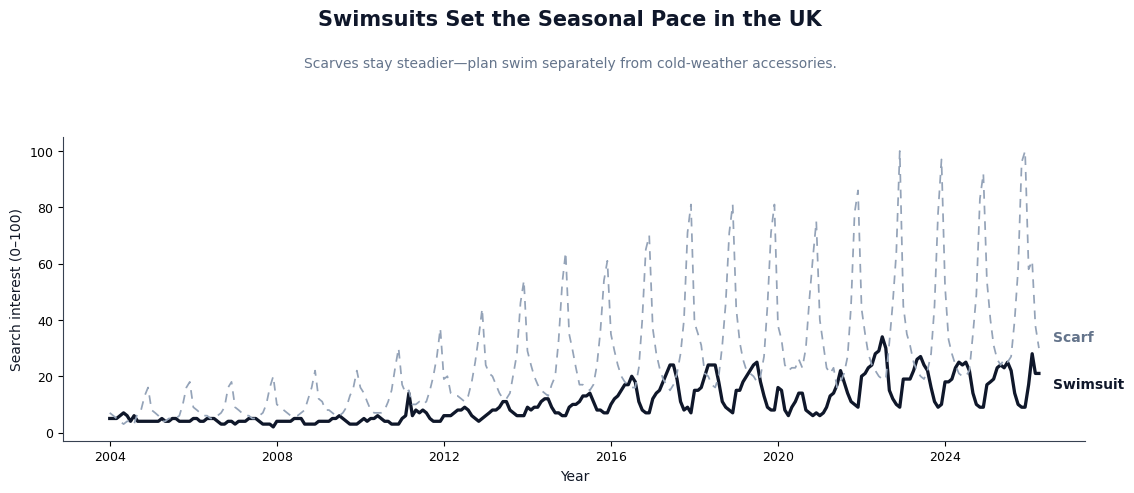

In [3]:
_chart_style()
fig, ax = plt.subplots(figsize=(11.5, 5.2))
ax.plot(tr["Month"], tr[uk_sw], color="#0f172a", linewidth=2.35, zorder=2)
ax.plot(tr["Month"], tr[uk_sc], color="#94a3b8", linewidth=1.25, linestyle=(0, (5, 4)), zorder=2)
ax.set_xlabel("Year")
ax.set_ylabel("Search interest (0–100)")
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
_deck_titles(
    fig,
    "Swimsuits Set the Seasonal Pace in the UK",
    "Scarves stay steadier—plan swim separately from cold-weather accessories.",
)
_end_meta = sorted(
    [
        (tr["Month"], tr[uk_sw], "Swimsuit", "#0f172a"),
        (tr["Month"], tr[uk_sc], "Scarf", "#64748b"),
    ],
    key=lambda t: float(t[1].iloc[-1]),
)
for (d, y, nm, col), dy in zip(_end_meta, [-8, 8]):
    _label_line_end(ax, d, y, nm, col, 10, dy)
plt.tight_layout(rect=[0, 0.03, 1, 0.82])
_save_chart(fig, "uk_swimsuit_scarf_seasonality.png")
plt.show()


## 1.3 New Zealand — separate line charts (swimsuit vs scarf)

Southern-hemisphere seasonality implies swimsuit peaks may appear **offset** vs the UK when viewed on a calendar-month axis.


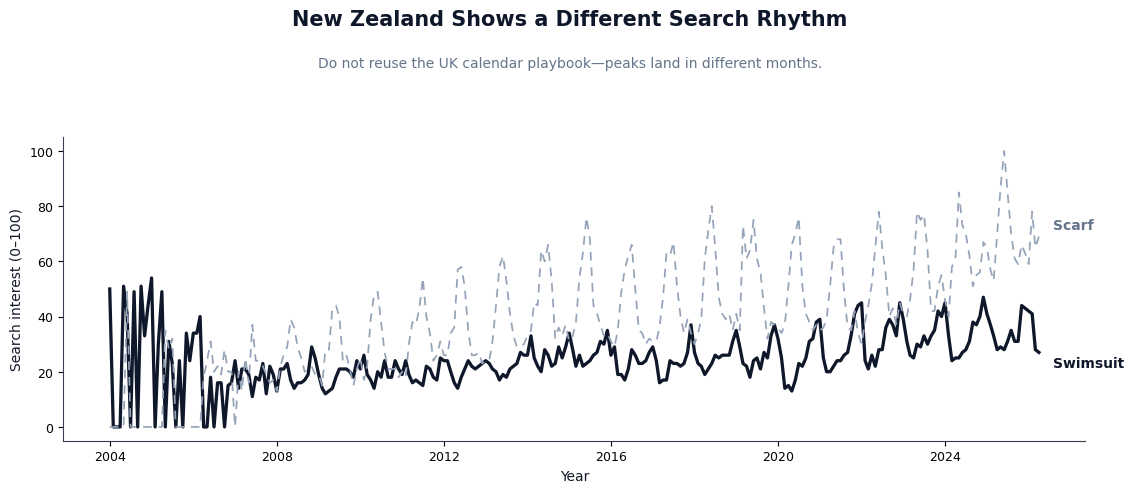

In [4]:
_chart_style()
fig, ax = plt.subplots(figsize=(11.5, 5.2))
ax.plot(tr["Month"], tr[nz_sw], color="#0f172a", linewidth=2.35, zorder=2)
ax.plot(tr["Month"], tr[nz_sc], color="#94a3b8", linewidth=1.25, linestyle=(0, (5, 4)), zorder=2)
ax.set_xlabel("Year")
ax.set_ylabel("Search interest (0–100)")
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
_deck_titles(
    fig,
    "New Zealand Shows a Different Search Rhythm",
    "Do not reuse the UK calendar playbook—peaks land in different months.",
)
_end_meta = sorted(
    [
        (tr["Month"], tr[nz_sw], "Swimsuit", "#0f172a"),
        (tr["Month"], tr[nz_sc], "Scarf", "#64748b"),
    ],
    key=lambda t: float(t[1].iloc[-1]),
)
for (d, y, nm, col), dy in zip(_end_meta, [-8, 8]):
    _label_line_end(ax, d, y, nm, col, 10, dy)
plt.tight_layout(rect=[0, 0.03, 1, 0.82])
_save_chart(fig, "nz_swimsuit_scarf_seasonality.png")
plt.show()


## 1.4 Correlation within each country (verify prior work)

Prior manual check reported **UK ≈ 0.135** and **NZ ≈ 0.166**. We recompute Pearson correlation on aligned monthly series (pairwise complete).


In [5]:
r_uk = tr[uk_sw].corr(tr[uk_sc])
r_nz = tr[nz_sw].corr(tr[nz_sc])
print(f"Pearson UK ({uk_sw} vs {uk_sc}): {r_uk:.4f}")
print(f"Pearson NZ ({nz_sw} vs {nz_sc}): {r_nz:.4f}")
print("\nNote: small positive r suggests weak co-movement; seasonal structure is clearer in charts than in a single correlation.")


Pearson UK (UK swimsuit vs UK scarf): 0.1461
Pearson NZ (NZ swimsuit vs NZ scarf): 0.1656

Note: small positive r suggests weak co-movement; seasonal structure is clearer in charts than in a single correlation.


## 1.5 Within-country comparison (stacked panels removed)

Earlier drafts used duplicate stacked panels; the cleaner UK/NZ seasonality PNGs above already carry the insight, so the code cell below is intentionally a no-op to avoid repeating the same story.


In [6]:
# Stacked UK/NZ swimsuit+scarf panels removed: they repeated the story told in
# uk_swimsuit_scarf_seasonality.png and nz_swimsuit_scarf_seasonality.png.
pass


## 1.6 Cross-country comparison (same product, different markets)

These charts highlight **phase differences** (summer vs winter calendars) and help communicate a **portfolio / timing** narrative without claiming absolute demand.


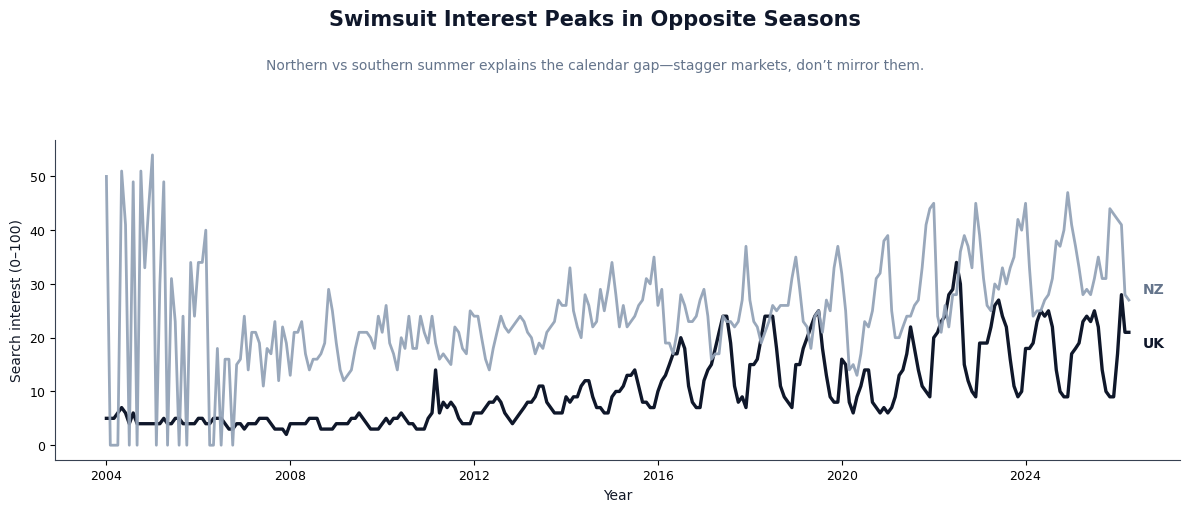

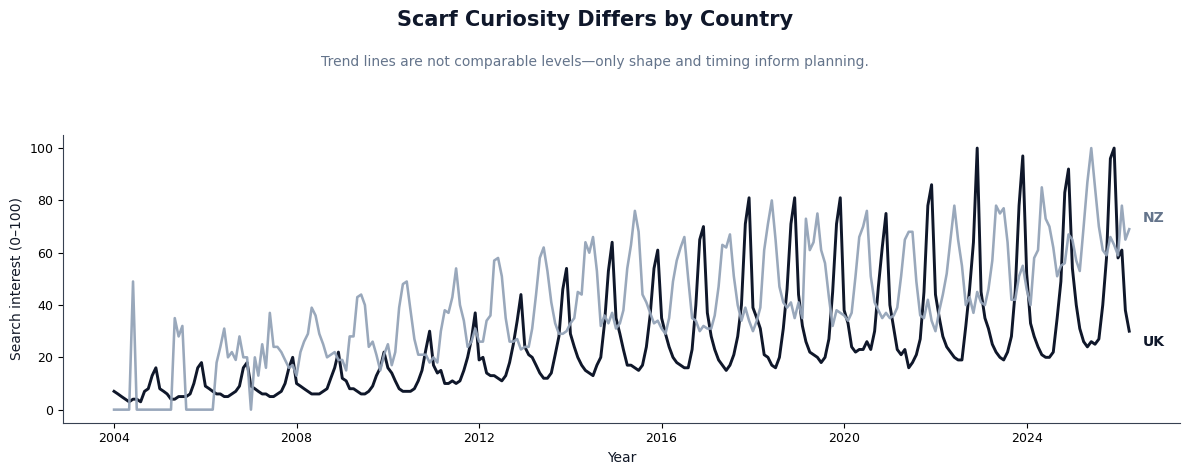

/var/folders/7r/fvw879pj3cl9wk9w_q_lwdvm0000gn/T/ipykernel_94225/2922362949.py:80: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [7]:
_chart_style()
# Swimsuits UK vs NZ — hemisphere shift
fig, ax = plt.subplots(figsize=(12, 5.4))
ax.plot(tr["Month"], tr[uk_sw], color="#0f172a", linewidth=2.4, label="_uk", zorder=2)
ax.plot(tr["Month"], tr[nz_sw], color="#94a3b8", linewidth=2.0, alpha=0.95, zorder=2)
ax.set_xlabel("Year")
ax.set_ylabel("Search interest (0–100)")
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
_deck_titles(
    fig,
    "Swimsuit Interest Peaks in Opposite Seasons",
    "Northern vs southern summer explains the calendar gap—stagger markets, don’t mirror them.",
)
_end_meta = sorted(
    [
        (tr["Month"], tr[uk_sw], "UK", "#0f172a"),
        (tr["Month"], tr[nz_sw], "NZ", "#64748b"),
    ],
    key=lambda t: float(t[1].iloc[-1]),
)
for (d, y, nm, col), dy in zip(_end_meta, [-8, 8]):
    _label_line_end(ax, d, y, nm, col, 10, dy)
plt.tight_layout(rect=[0, 0.03, 1, 0.82])
_save_chart(fig, "swimsuit_uk_vs_nz_hemisphere_shift.png")
plt.show()

# Scarves — one clean comparison (keep single insight)
fig, ax = plt.subplots(figsize=(12, 5.0))
ax.plot(tr["Month"], tr[uk_sc], color="#0f172a", linewidth=2.1, zorder=2)
ax.plot(tr["Month"], tr[nz_sc], color="#94a3b8", linewidth=1.85, alpha=0.95, zorder=2)
ax.set_xlabel("Year")
ax.set_ylabel("Search interest (0–100)")
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
_deck_titles(
    fig,
    "Scarf Curiosity Differs by Country",
    "Trend lines are not comparable levels—only shape and timing inform planning.",
)
_end_meta = sorted(
    [
        (tr["Month"], tr[uk_sc], "UK", "#0f172a"),
        (tr["Month"], tr[nz_sc], "NZ", "#64748b"),
    ],
    key=lambda t: float(t[1].iloc[-1]),
)
for (d, y, nm, col), dy in zip(_end_meta, [-8, 8]):
    _label_line_end(ax, d, y, nm, col, 10, dy)
plt.tight_layout(rect=[0, 0.03, 1, 0.82])
_save_chart(fig, "scarf_uk_vs_nz_comparison.png")
plt.show()


### Part 1 — Markdown takeaways (for report)

Google Trends measures relative search interest within each market and period. It is used here to analyze timing and seasonality, not absolute market demand.

- **Seasonality:** swimsuit series show recurring peaks consistent with **warm-season** interest; scarf shows a different rhythm (less coincident with swimsuit peaks).
- **Phase shift:** UK vs NZ swimsuit peaks can occur in **different calendar months**, consistent with **opposite summer seasons** — useful for staggering marketing/production emphasis.
- **Correlation:** within-country correlations are **small positive** values; this supports “**weak linear co-movement**” while still allowing strong **seasonal structure** visible in plots.
- **Do not** interpret levels as absolute sales potential.


---

# Part 2 — Internal FabricCo KPI dataset

## 2.1 Data preparation — parse dates, add `Year`

We use explicit `format` where possible for `m/d/y` month-end stamps in the CSV.


In [8]:
products = ["Beanies", "Bikinis", "Hoodies", "Summer_Shirts", "Rain_Coats"]

fabric_path = BASE / "FabricCo_Full_Products_Corrected_KPIs_2004_2024.csv"
fabric = pd.read_csv(fabric_path)
fabric["Date"] = pd.to_datetime(fabric["Date"], format="%m/%d/%y", errors="coerce")
if fabric["Date"].isna().mean() > 0.05:
    fabric["Date"] = pd.to_datetime(fabric["Date"], errors="coerce")

fabric["Year"] = fabric["Date"].dt.year
fabric = fabric.sort_values("Date").reset_index(drop=True)

print("Rows:", len(fabric), "| Month range:", fabric["Date"].min(), "→", fabric["Date"].max())
print("Years:", int(fabric["Year"].min()), "–", int(fabric["Year"].max()))
fabric.head(2)


Rows: 252 | Month range: 2004-01-31 00:00:00 → 2024-12-31 00:00:00
Years: 2004 – 2024


,Date,Beanies_COGS,Beanies_Sold_Units,Beanies_Gross_Profit_Margin,Beanies_Production_Cost,Beanies_Inventory_Turnover,Beanies_Capacity_Utilization,Beanies_Lead_Time_Days,Beanies_Market_Share,Beanies_Customer_Satisfaction_Score,...,Rain_Coats_Sold_Units,Rain_Coats_Gross_Profit_Margin,Rain_Coats_Production_Cost,Rain_Coats_Inventory_Turnover,Rain_Coats_Capacity_Utilization,Rain_Coats_Lead_Time_Days,Rain_Coats_Market_Share,Rain_Coats_Customer_Satisfaction_Score,Rain_Coats_Items_Returned,Year
0,2004-01-31,17044,221,0.254196,24740,4.247530,0.762251,24,9.578661,8.905427,...,256,0.395463,18362,5.553471,0.652118,36,6.700738,9.846175,18,2004
1,2004-02-29,12116,227,0.375272,15222,6.702254,0.816600,32,5.726256,9.089908,...,336,0.392175,20473,5.334568,0.606702,36,11.778787,7.830969,17,2004


## 2.2 Exploratory statistics (mean, median, std) by product

Metrics: **Sold_Units**, **Gross_Profit_Margin**, **Customer_Satisfaction_Score**, **Inventory_Turnover**.


In [9]:
metrics = {
    "Sold_Units": "Sold_Units",
    "Gross_Profit_Margin": "Gross_Profit_Margin",
    "Customer_Satisfaction_Score": "Customer_Satisfaction_Score",
    "Inventory_Turnover": "Inventory_Turnover",
}

rows = []
for prod in products:
    for nice, suf in metrics.items():
        col = f"{prod}_{suf}"
        s = fabric[col]
        rows.append(
            {
                "Product": prod.replace("_", " "),
                "Metric": nice,
                "Mean": s.mean(),
                "Median": s.median(),
                "Std": s.std(),
            }
        )

stats_tbl = pd.DataFrame(rows)
print(stats_tbl.to_string(index=False))

mean_wide = stats_tbl.pivot(index="Product", columns="Metric", values="Mean")
print("\nMeans — wide:")
print(mean_wide.round(4).to_string())


      Product                      Metric       Mean     Median       Std
      Beanies                  Sold_Units 355.523810 364.000000 88.997579
      Beanies         Gross_Profit_Margin   0.298047   0.294837  0.056265
      Beanies Customer_Satisfaction_Score   8.569846   8.629401  0.810817
      Beanies          Inventory_Turnover   5.508570   5.541820  0.870712
      Bikinis                  Sold_Units 342.579365 341.000000 87.427316
      Bikinis         Gross_Profit_Margin   0.303187   0.302870  0.057342
      Bikinis Customer_Satisfaction_Score   8.537380   8.523212  0.835084
      Bikinis          Inventory_Turnover   5.505701   5.496476  0.845872
      Hoodies                  Sold_Units 350.591270 354.000000 86.938017
      Hoodies         Gross_Profit_Margin   0.296447   0.295328  0.055521
      Hoodies Customer_Satisfaction_Score   8.416073   8.372712  0.854735
      Hoodies          Inventory_Turnover   5.484309   5.460916  0.829483
Summer Shirts                  Sold_Un

## 2.3 Yearly trends (aggregated to reduce monthly noise)

Rules used (business-readable defaults):
- **Sold_Units:** sum within year (annual volume proxy)
- **Gross_Profit_Margin, Customer_Satisfaction_Score, Inventory_Turnover:** annual mean of monthly values


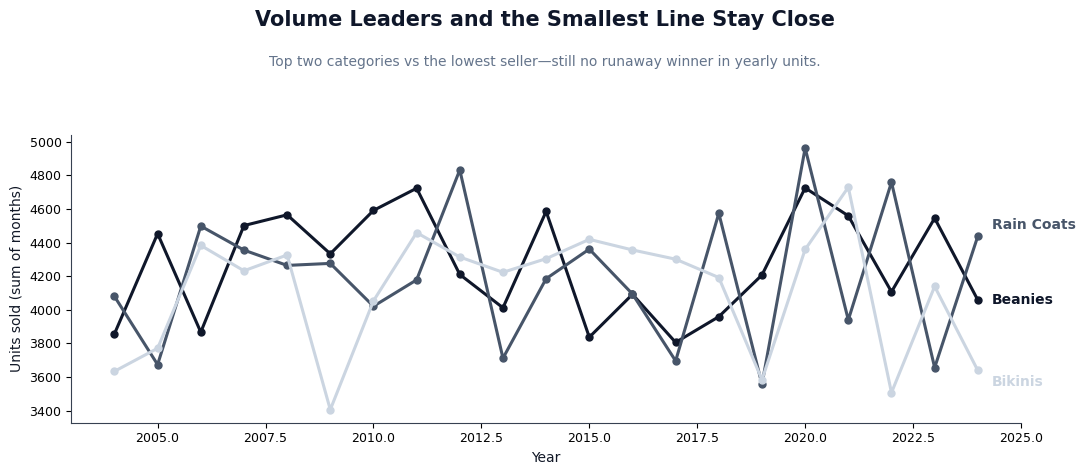

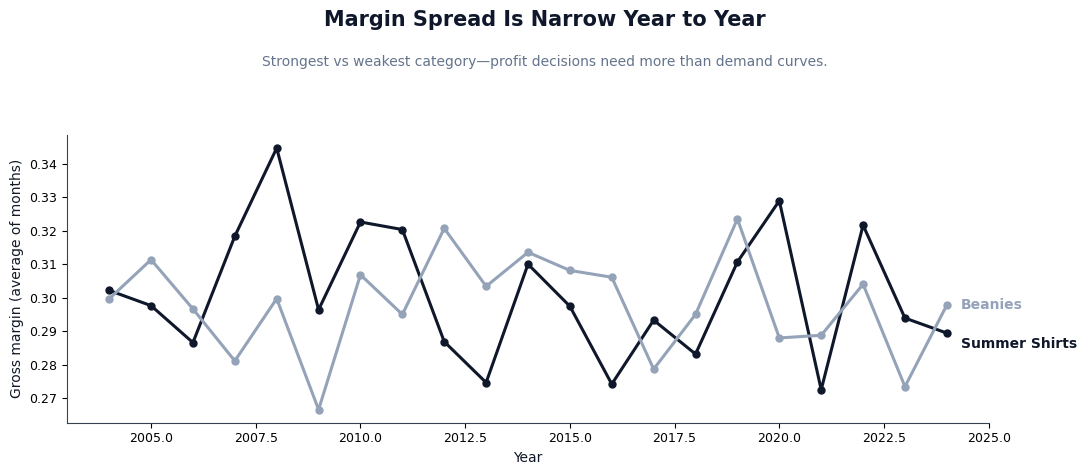

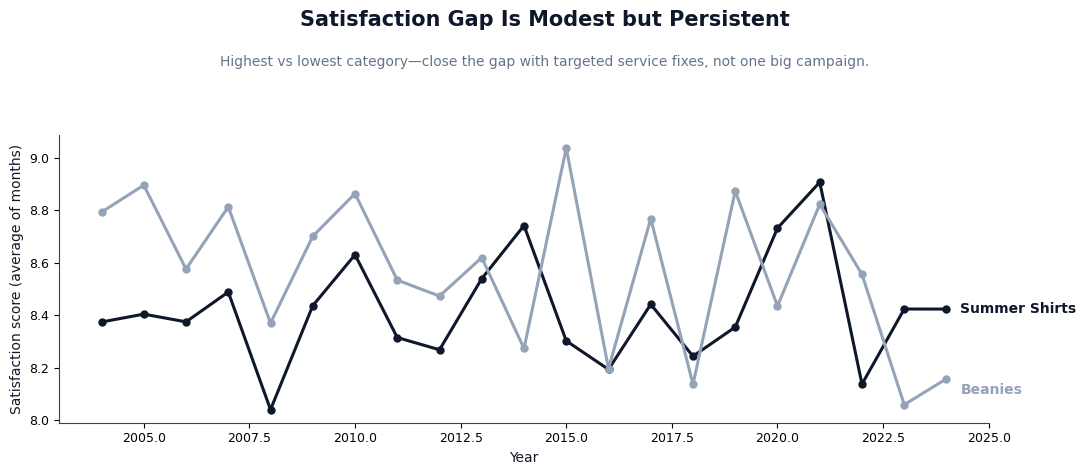

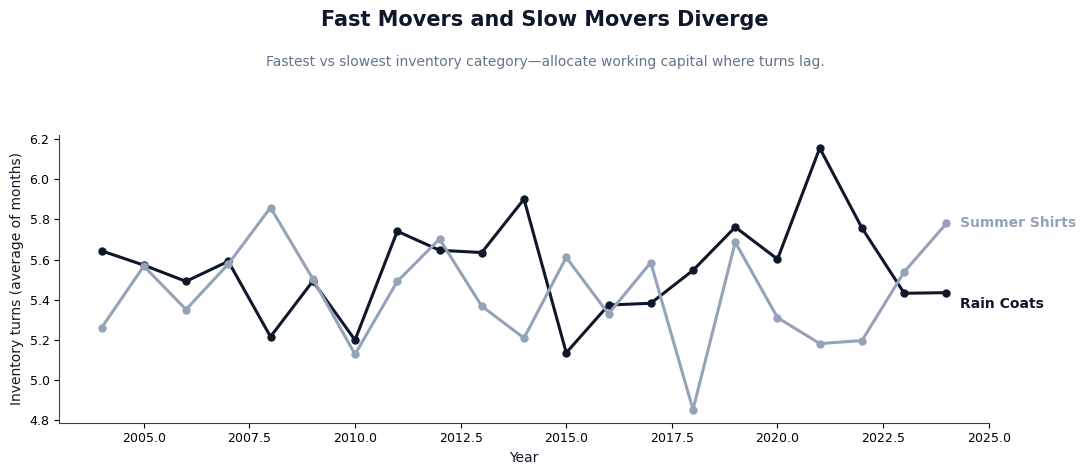

In [10]:
agg_map = {}
for p in products:
    agg_map[f"{p}_Sold_Units"] = "sum"
    agg_map[f"{p}_Gross_Profit_Margin"] = "mean"
    agg_map[f"{p}_Customer_Satisfaction_Score"] = "mean"
    agg_map[f"{p}_Inventory_Turnover"] = "mean"

yearly = fabric.groupby("Year", as_index=False).agg(agg_map)

_chart_style()

recent5 = fabric[fabric["Year"].between(2020, 2024)]
vol = {p: recent5[f"{p}_Sold_Units"].sum() for p in products}
vol_sorted = sorted(vol.items(), key=lambda x: x[1], reverse=True)
top2_vol = [p for p, _ in vol_sorted[:2]]
bottom1_vol = [vol_sorted[-1][0]]

margin_sorted = sorted(
    products, key=lambda p: recent5[f"{p}_Gross_Profit_Margin"].mean(), reverse=True
)
margin_hi, margin_lo = margin_sorted[0], margin_sorted[-1]

turn_sorted = sorted(
    products, key=lambda p: recent5[f"{p}_Inventory_Turnover"].mean(), reverse=True
)
turn_hi, turn_lo = turn_sorted[0], turn_sorted[-1]

sat_sorted = sorted(
    products, key=lambda p: recent5[f"{p}_Customer_Satisfaction_Score"].mean(), reverse=True
)
sat_hi, sat_lo = sat_sorted[0], sat_sorted[-1]


def _plot_yearly_lines(metric_suffix, ylabel, prods, colors, title, subtitle, fname):
    fig, ax = plt.subplots(figsize=(11, 5.0))
    dy_cycle = (-8, 0, 8)
    last_rows = []
    for p, col in zip(prods, colors):
        cname = f"{p}_{metric_suffix}"
        last_rows.append((p, col, float(yearly[cname].iloc[-1])))
    last_rows.sort(key=lambda t: t[2])
    dy_map = {p: dy_cycle[i % 3] for i, (p, _, _) in enumerate(last_rows)}
    for p, col in zip(prods, colors):
        cname = f"{p}_{metric_suffix}"
        ax.plot(
            yearly["Year"],
            yearly[cname],
            marker="o",
            markersize=5,
            linewidth=2.2,
            color=col,
        )
        dy = dy_map[p]
        _label_line_end(ax, yearly["Year"], yearly[cname], p.replace("_", " "), col, 10, dy)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    _deck_titles(fig, title, subtitle)
    plt.tight_layout(rect=[0, 0.03, 1, 0.82])
    _save_chart(fig, fname)
    plt.show()


_plot_yearly_lines(
    "Sold_Units",
    "Units sold (sum of months)",
    top2_vol + bottom1_vol,
    ["#0f172a", "#475569", "#cbd5e1"],
    "Volume Leaders and the Smallest Line Stay Close",
    "Top two categories vs the lowest seller—still no runaway winner in yearly units.",
    "yearly_units_top_two_vs_bottom_one.png",
)
_plot_yearly_lines(
    "Gross_Profit_Margin",
    "Gross margin (average of months)",
    [margin_hi, margin_lo],
    ["#0f172a", "#94a3b8"],
    "Margin Spread Is Narrow Year to Year",
    "Strongest vs weakest category—profit decisions need more than demand curves.",
    "yearly_margin_strongest_vs_weakest.png",
)
_plot_yearly_lines(
    "Customer_Satisfaction_Score",
    "Satisfaction score (average of months)",
    [sat_hi, sat_lo],
    ["#0f172a", "#94a3b8"],
    "Satisfaction Gap Is Modest but Persistent",
    "Highest vs lowest category—close the gap with targeted service fixes, not one big campaign.",
    "yearly_satisfaction_highest_vs_lowest.png",
)
_plot_yearly_lines(
    "Inventory_Turnover",
    "Inventory turns (average of months)",
    [turn_hi, turn_lo],
    ["#0f172a", "#94a3b8"],
    "Fast Movers and Slow Movers Diverge",
    "Fastest vs slowest inventory category—allocate working capital where turns lag.",
    "yearly_turnover_fastest_vs_slowest.png",
)


## 2.4 Product comparison — last five calendar years (2020–2024)

Rankings use simple aggregates over that window:
- Popularity: **sum** `Sold_Units`
- Profitability: **mean** `Gross_Profit_Margin`
- Efficiency: **mean** `Inventory_Turnover` and **mean** `Capacity_Utilization`
- Satisfaction: **mean** `Customer_Satisfaction_Score`; returns: **sum** `Items_Returned` (lower returns better)


               Sold_Units_sum  Gross_Profit_Margin_mean  \
Product                                                   
Beanies                 21994                    0.2905   
Bikinis                 20373                    0.3000   
Hoodies                 20788                    0.2965   
Summer Shirts           21308                    0.3013   
Rain Coats              21755                    0.2978   

               Inventory_Turnover_mean  Capacity_Utilization_mean  \
Product                                                             
Beanies                         5.5583                     0.7256   
Bikinis                         5.4603                     0.7452   
Hoodies                         5.4683                     0.7595   
Summer Shirts                   5.4018                     0.7433   
Rain Coats                      5.6766                     0.7444   

               Customer_Satisfaction_mean  Items_Returned_sum  
Product                               

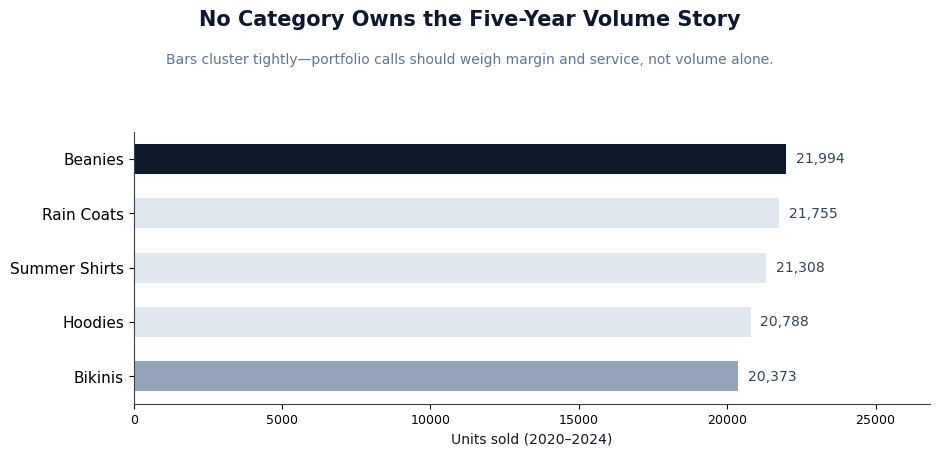

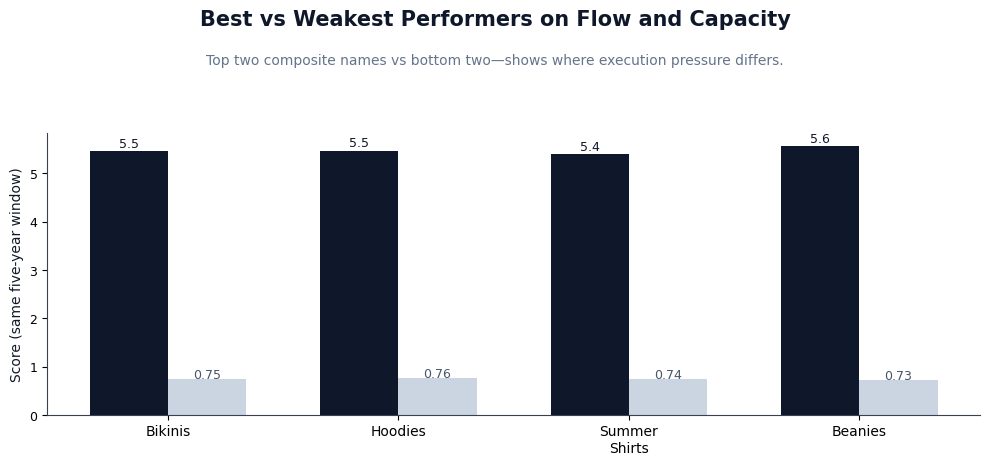

In [11]:
recent = fabric[fabric["Year"].between(2020, 2024)].copy()
summary = []
for p in products:
    summary.append(
        {
            "Product": p.replace("_", " "),
            "Sold_Units_sum": recent[f"{p}_Sold_Units"].sum(),
            "Gross_Profit_Margin_mean": recent[f"{p}_Gross_Profit_Margin"].mean(),
            "Inventory_Turnover_mean": recent[f"{p}_Inventory_Turnover"].mean(),
            "Capacity_Utilization_mean": recent[f"{p}_Capacity_Utilization"].mean(),
            "Customer_Satisfaction_mean": recent[f"{p}_Customer_Satisfaction_Score"].mean(),
            "Items_Returned_sum": recent[f"{p}_Items_Returned"].sum(),
        }
    )

sdf = pd.DataFrame(summary).set_index("Product")
print(sdf.round(4))

ranks = pd.DataFrame(index=sdf.index)
ranks["Popularity_rank"] = sdf["Sold_Units_sum"].rank(ascending=False)
ranks["Margin_rank"] = sdf["Gross_Profit_Margin_mean"].rank(ascending=False)
ranks["InvTurn_rank"] = sdf["Inventory_Turnover_mean"].rank(ascending=False)
ranks["CapUtil_rank"] = sdf["Capacity_Utilization_mean"].rank(ascending=False)
ranks["Sat_rank"] = sdf["Customer_Satisfaction_mean"].rank(ascending=False)
ranks["Returns_rank"] = sdf["Items_Returned_sum"].rank(ascending=True)

print("\nAverage rank (1=best) across six dimensions:")
avg_rank = ranks.mean(axis=1).sort_values()
print(avg_rank.round(2).to_string())

best = avg_rank.index[0]
worst = avg_rank.index[-1]
print("\nHeuristic 'best overall' (lowest average rank):", best)
print("Heuristic 'worst overall' (highest average rank):", worst)

_chart_style()
vol = sdf["Sold_Units_sum"].sort_values()
fig, ax = plt.subplots(figsize=(9.5, 4.8))
colors = ["#e2e8f0"] * len(vol)
colors[vol.index.get_loc(vol.idxmin())] = "#94a3b8"
colors[vol.index.get_loc(vol.idxmax())] = "#0f172a"
ax.barh(vol.index, vol.values, color=colors, height=0.55)
ax.set_xlabel("Units sold (2020–2024)")
for i, (idx, v) in enumerate(vol.items()):
    ax.text(v + max(vol) * 0.015, i, f"{int(v):,}", va="center", fontsize=10, color="#334155")
ax.set_xlim(0, max(vol) * 1.22)
ax.set_yticks(range(len(vol)))
ax.set_yticklabels(vol.index, fontsize=11)
_deck_titles(
    fig,
    "No Category Owns the Five-Year Volume Story",
    "Bars cluster tightly—portfolio calls should weigh margin and service, not volume alone.",
)
plt.tight_layout(rect=[0, 0.03, 1, 0.82])
_save_chart(fig, "five_year_volume_no_single_leader.png")
plt.show()

rank_order = avg_rank.sort_values().index.tolist()
focus_hi = rank_order[:2]
focus_lo = rank_order[-2:]
fig, ax = plt.subplots(figsize=(10, 4.9))
x = np.arange(len(focus_hi) + len(focus_lo))
labels = [p.replace(" ", "\n") for p in focus_hi + focus_lo]
turn = [sdf.loc[p, "Inventory_Turnover_mean"] for p in focus_hi + focus_lo]
cap = [sdf.loc[p, "Capacity_Utilization_mean"] for p in focus_hi + focus_lo]
w = 0.34
bars1 = ax.bar(x - w / 2, turn, width=w, color="#0f172a")
bars2 = ax.bar(x + w / 2, cap, width=w, color="#cbd5e1")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Score (same five-year window)")
for b, val in zip(bars1, turn):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.08, f"{val:.1f}", ha="center", fontsize=9, color="#0f172a")
for b, val in zip(bars2, cap):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02, f"{val:.2f}", ha="center", fontsize=9, color="#475569")
_deck_titles(
    fig,
    "Best vs Weakest Performers on Flow and Capacity",
    "Top two composite names vs bottom two—shows where execution pressure differs.",
)
plt.tight_layout(rect=[0, 0.03, 1, 0.82])
_save_chart(fig, "five_year_efficiency_composite_split.png")
plt.show()


## 2.5 Correlation analysis (pooled product-month observations)

Each month generates **five rows** (one per product). Correlations are **descriptive** and do not imply causality.


Service vs. returns: Pearson r = 0.001
Turns vs. margin: Pearson r = 0.038
Capacity vs. lead time: Pearson r = -0.030


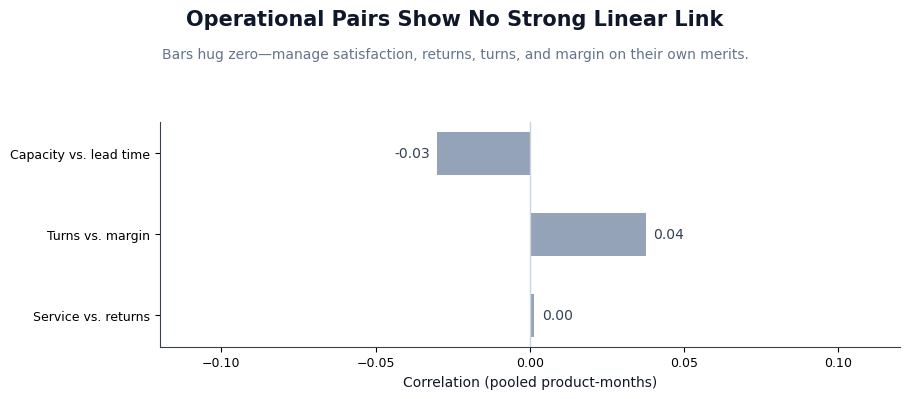

In [12]:
long_rows = []
for _, row in fabric.iterrows():
    for p in products:
        long_rows.append(
            {
                "Product": p,
                "Customer_Satisfaction_Score": row[f"{p}_Customer_Satisfaction_Score"],
                "Items_Returned": row[f"{p}_Items_Returned"],
                "Inventory_Turnover": row[f"{p}_Inventory_Turnover"],
                "Gross_Profit_Margin": row[f"{p}_Gross_Profit_Margin"],
                "Capacity_Utilization": row[f"{p}_Capacity_Utilization"],
                "Lead_Time_Days": row[f"{p}_Lead_Time_Days"],
            }
        )

long_df = pd.DataFrame(long_rows)

pairs = [
    ("Customer_Satisfaction_Score", "Items_Returned", "Service vs. returns"),
    ("Inventory_Turnover", "Gross_Profit_Margin", "Turns vs. margin"),
    ("Capacity_Utilization", "Lead_Time_Days", "Capacity vs. lead time"),
]
rs = []
for x, y, lab in pairs:
    r = long_df[x].corr(long_df[y])
    rs.append((lab, r))
    print(f"{lab}: Pearson r = {r:.3f}")

_chart_style()
fig, ax = plt.subplots(figsize=(9.2, 4.2))
labels = [a for a, _ in rs]
vals = [b for _, b in rs]
colors = ["#0f172a" if abs(v) >= 0.08 else "#94a3b8" for v in vals]
bars = ax.barh(labels, vals, color=colors, height=0.52)
ax.axvline(0, color="#cbd5e1", linewidth=1.0)
span = max(0.12, max(abs(v) for v in vals) * 1.35)
ax.set_xlim(-span, span)
for b, v in zip(bars, vals):
    xpos = v + (0.02 * span if v >= 0 else -0.02 * span)
    ha = "left" if v >= 0 else "right"
    ax.text(xpos, b.get_y() + b.get_height() / 2, f"{v:.2f}", va="center", ha=ha, fontsize=10, color="#334155")
ax.set_xlabel("Correlation (pooled product-months)")
_deck_titles(
    fig,
    "Operational Pairs Show No Strong Linear Link",
    "Bars hug zero—manage satisfaction, returns, turns, and margin on their own merits.",
)
plt.tight_layout(rect=[0, 0.03, 1, 0.82])
_save_chart(fig, "operational_metrics_correlation_summary.png")
plt.show()


In [13]:
# Auto-generated bullets (run after Part 2 cells so `fabric` exists)
products = ["Beanies", "Bikinis", "Hoodies", "Summer_Shirts", "Rain_Coats"]
recent = fabric[fabric["Year"].between(2020, 2024)].copy()
summary = []
for p in products:
    summary.append({
        "Product": p.replace("_", " "),
        "Sold_Units_sum": recent[f"{p}_Sold_Units"].sum(),
        "Gross_Profit_Margin_mean": recent[f"{p}_Gross_Profit_Margin"].mean(),
        "Inventory_Turnover_mean": recent[f"{p}_Inventory_Turnover"].mean(),
        "Capacity_Utilization_mean": recent[f"{p}_Capacity_Utilization"].mean(),
        "Customer_Satisfaction_mean": recent[f"{p}_Customer_Satisfaction_Score"].mean(),
        "Items_Returned_sum": recent[f"{p}_Items_Returned"].sum(),
    })
sdf = pd.DataFrame(summary).set_index("Product")
ranks = pd.DataFrame(index=sdf.index)
ranks["Popularity_rank"] = sdf["Sold_Units_sum"].rank(ascending=False)
ranks["Margin_rank"] = sdf["Gross_Profit_Margin_mean"].rank(ascending=False)
ranks["InvTurn_rank"] = sdf["Inventory_Turnover_mean"].rank(ascending=False)
ranks["CapUtil_rank"] = sdf["Capacity_Utilization_mean"].rank(ascending=False)
ranks["Sat_rank"] = sdf["Customer_Satisfaction_mean"].rank(ascending=False)
ranks["Returns_rank"] = sdf["Items_Returned_sum"].rank(ascending=True)
avg_rank = ranks.mean(axis=1).sort_values()
best, worst = avg_rank.index[0], avg_rank.index[-1]
print("--- COPY: Strategic bullets (data-driven) ---")
print("- Slide figures: outputs/charts/ (see ANALYSIS_SUMMARY.txt for what each PNG is for).")
print(f"- Prioritize expansion: **{best}** (best average rank across 2020–2024 popularity, margin, turnover, utilization, satisfaction, returns).")
print(f"- Revise or rationalize: **{worst}** (weakest average rank in the same composite view).")
print("- Inventory: use yearly turnover charts + 2020–2024 efficiency bars to tighten purchasing on lagging SKUs.")
print("- Customer satisfaction: pooled correlations are weak; run product-specific return reviews and defect tracking.")
try:
    print(f"- External: UK swimsuit–scarf correlation ≈ {r_uk:.3f}; NZ ≈ {r_nz:.3f} (weak; rely on seasonal charts).")
except NameError:
    print("- External: run Part 1 correlation cell for UK/NZ r values.")


--- COPY: Strategic bullets (data-driven) ---
- Slide figures: outputs/charts/ (see ANALYSIS_SUMMARY.txt for what each PNG is for).
- Prioritize expansion: **Bikinis** (best average rank across 2020–2024 popularity, margin, turnover, utilization, satisfaction, returns).
- Revise or rationalize: **Beanies** (weakest average rank in the same composite view).
- Inventory: use yearly turnover charts + 2020–2024 efficiency bars to tighten purchasing on lagging SKUs.
- Customer satisfaction: pooled correlations are weak; run product-specific return reviews and defect tracking.
- External: UK swimsuit–scarf correlation ≈ 0.146; NZ ≈ 0.166 (weak; rely on seasonal charts).


## 2.6 Strategic insights (draft for Sophie & Andy)

Fill names/course on the final report cover page. The bullets below should be **edited** after you review the printed tables/charts from your run.

### Which product to prioritize for expansion
- Prefer the product that combines **strong 2020–2024 volume**, **healthy margin**, **reasonable returns**, and **stable or improving** yearly satisfaction/turnover trends in Section 2.3–2.4 charts.

### Which product to discontinue or revise
- Target a product with **weak multi-metric performance** (low turnover and/or low utilization can signal sluggish flow or under-used capacity depending on context) **and/or** **high returns / weaker satisfaction**, especially if not compensated by margin.

### Two actionable strategies (aligned to this notebook’s findings)
1. **Returns and satisfaction (pooled view):** The pooled product-month correlation between satisfaction and returns is effectively **zero** in this dataset, so do **not** assume a neat linear trade-off. Run **SKU-level** return reviews (fit, defects, fulfillment) and track satisfaction by product over time instead of relying on a global correlation.
2. **Flow vs margin:** Turnover and margin also show a **very weak** linear link in the pooled panel—manage inventory turns and margin with **separate** targets and product-specific yearly charts rather than one implied “lever.”

Because volume differences are narrow, product decisions should rely more on profitability, efficiency, and customer experience than on units sold alone.

> Re-run the notebook after any data updates; numbers in exported charts/tables in the report should match executed notebook outputs. Re-run `python3 build_analysis_package_xlsx.py` so **FabricCo_Analysis_Package.xlsx** stays aligned.
